# Lab 0-01: Train a Tiny LLM on a Book Excerpt

This notebook trains a tiny word-level decoder-only Transformer on a short public-domain excerpt from *The Wonderful Wizard of Oz*.

The goal is not to build a production LLM. The goal is to let you see a small training loop, watch loss improve, and inspect how a trained model predicts likely next words from context.


## Step 1: Setup

This notebook uses only local files and PyTorch. It does not require Ollama or `.env`.

If the next cell fails on the `torch` import, install the base course dependencies from the repo root first:

```bash
pip install -r requirements.txt
```


In [1]:
# Import standard Python tools: random choices, text matching, timing, and file paths.
import random
import re
import time
from pathlib import Path

# PyTorch provides the tensors (number grids) and neural-network building blocks.
try:
    import matplotlib.pyplot as plt
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'PyTorch and Matplotlib are required for this notebook. Run `pip install -r requirements.txt` from the repo root and try again.'
    ) from exc

# Check that the notebook is running from the expected lab folder.
# This makes relative paths such as data/... reliable.
LAB_NAME = 'lab0_01_llm_foundations'
lab_dir = Path.cwd().resolve()
if lab_dir.name != LAB_NAME:
    raise FileNotFoundError(f'Open this notebook from the {LAB_NAME} folder.')

data_dir = lab_dir / 'data'
corpus_path = data_dir / 'wizard_of_oz_excerpt.txt'
if not corpus_path.exists():
    raise FileNotFoundError('Could not find wizard_of_oz_excerpt.txt in data/.')

# Use fixed seeds so random choices are repeatable when students rerun the notebook.
random.seed(7)
torch.manual_seed(7)

# Use a GPU when one is available; otherwise, the model still runs on the CPU.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Lab folder:', lab_dir)
print('Corpus path:', corpus_path)
print('Torch version:', torch.__version__)
print('Device:', device)


Lab folder: /home/frank/projects/agentic-AI4-forensics/lab0_01_llm_foundations
Corpus path: /home/frank/projects/agentic-AI4-forensics/lab0_01_llm_foundations/data/wizard_of_oz_excerpt.txt
Torch version: 2.11.0+cu130
Device: cpu


/home/frank/projects/agentic-AI4-forensics/.venv-ai4-forensics/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Step 2: Load the Book Excerpt

The corpus is a short public-domain excerpt from *The Wonderful Wizard of Oz*.

To keep the training visible on classroom hardware, the notebook will repeat this excerpt several times. That repeated corpus is still only a teaching dataset, not a realistic training corpus.


In [2]:
# Read the source file as one long string and remove extra whitespace at the ends.
raw_text = corpus_path.read_text(encoding='utf-8').strip()
# Show only the beginning so the notebook output stays readable.
print(raw_text[:1800])
print('\n---')
print('Original excerpt character count:', len(raw_text))
print('Original excerpt word count:', len(raw_text.split()))


Dorothy lived in the midst of the great Kansas prairies, with Uncle Henry, who was a farmer, and Aunt Em, who was the farmer's wife. Their house was small, for the lumber to build it had to be carried by wagon many miles. There were four walls, a floor and a roof, which made one room; and this room contained a rusty looking cooking stove, a cupboard for the dishes, a table, three or four chairs, and the beds. Uncle Henry and Aunt Em had a big bed in one corner, and Dorothy a little bed in another corner.

There was no garret at all, and no cellar except a small hole, dug in the ground, called a cyclone cellar, where the family could go in case one of those great whirlwinds arose, mighty enough to crush any building in its path. It was reached by a trap-door in the middle of the floor, from which a ladder led down into the small, dark hole.

When Dorothy stood in the doorway and looked around, she could see nothing but the great gray prairie on every side. Not a tree nor a house broke t

## Step 3: Tokenize at the Word Level

This notebook uses a simple word-level tokenizer with punctuation tokens.

Real LLMs often use more advanced subword tokenization. Here we keep the tokenizer simple so students can focus on the training and prediction steps.


In [3]:
# Repeat the small excerpt so this tiny model sees its patterns often enough to learn them.
repeat_factor = 6
training_text = '\n\n'.join([raw_text] * repeat_factor)

# This simple pattern treats words and punctuation marks as separate tokens.
token_pattern = re.compile(r"[A-Za-z']+|[.,;:!?\-]")

def tokenize(text: str) -> list[str]:
    # Lowercase the text, then return every word or punctuation token it finds.
    return token_pattern.findall(text.lower())

def detokenize(tokens: list[str]) -> str:
    # Turn a list of tokens back into readable text for display.
    pieces = []
    punctuation = {'.', ',', ';', ':', '!', '?'}
    for token in tokens:
        if token in punctuation and pieces:
            pieces[-1] += token
        elif token == '-' and pieces:
            pieces[-1] += token
        else:
            pieces.append(token)
    return ' '.join(pieces)

# Build the vocabulary: every unique token the model is allowed to use.
tokens = tokenize(training_text)
vocab = sorted(set(tokens))
# Create two lookup tables: token -> ID and ID -> token.
stoi = {token: index for index, token in enumerate(vocab)}
itos = {index: token for token, index in stoi.items()}

def encode(token_list: list[str]) -> list[int]:
    # Replace each readable token with the number the model uses internally.
    return [stoi[token] for token in token_list]

def decode(index_list: list[int]) -> list[str]:
    # Convert model IDs back to readable tokens.
    return [itos[index] for index in index_list]

# Store the complete training text as one PyTorch tensor of token IDs.
ids = torch.tensor(encode(tokens), dtype=torch.long)

print('Repeat factor:', repeat_factor)
print('Token count:', len(tokens))
print('Vocabulary size:', len(vocab))
print('First 40 tokens:')
print(tokens[:40])


Repeat factor: 6
Token count: 7404
Vocabulary size: 405
First 40 tokens:
['dorothy', 'lived', 'in', 'the', 'midst', 'of', 'the', 'great', 'kansas', 'prairies', ',', 'with', 'uncle', 'henry', ',', 'who', 'was', 'a', 'farmer', ',', 'and', 'aunt', 'em', ',', 'who', 'was', 'the', "farmer's", 'wife', '.', 'their', 'house', 'was', 'small', ',', 'for', 'the', 'lumber', 'to', 'build']


## Step 4: Build Training and Validation Splits

The model will see short windows of context and learn to predict the next word at each position.


In [4]:
# Reserve the final 10% of tokens for validation, which the model does not train on.
split_index = int(0.9 * len(ids))
train_ids = ids[:split_index]
val_ids = ids[split_index:]

# The model may look back at 12 tokens at a time; this is its tiny context window.
block_size = 12
# A batch is 32 short training examples processed together.
batch_size = 32

def get_batch(split: str):
    # Choose either the training or validation portion of the book.
    data = train_ids if split == 'train' else val_ids
    # Pick random starting positions for several short text windows.
    starts = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    # x is the context. y is the same sequence shifted one token to the left:
    # each position in x should predict the token at the same position in y.
    x = torch.stack([data[start:start + block_size] for start in starts])
    y = torch.stack([data[start + 1:start + block_size + 1] for start in starts])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print('Train token count:', len(train_ids))
print('Validation token count:', len(val_ids))
print('One batch input shape:', tuple(xb.shape))
print('One batch target shape:', tuple(yb.shape))
print('Example input tokens:')
print(detokenize(decode(xb[0].tolist())))
print('\nExpected next-token targets:')
print(decode(yb[0].tolist()))


Train token count: 6663
Validation token count: 741
One batch input shape: (32, 12)
One batch target shape: (32, 12)
Example input tokens:
in her arms, and looked at the sky too. aunt

Expected next-token targets:
['her', 'arms', ',', 'and', 'looked', 'at', 'the', 'sky', 'too', '.', 'aunt', 'em']


## Step 5: Define a Tiny Decoder-Only Word-Level Transformer

This is a compact decoder-only (causal) Transformer. Its attention mask prevents each token from seeing future tokens, so it can use only prior context to predict the next token. It is still much smaller than a real production LLM, but it uses the same basic training idea.

**What is inside this tiny model?** It has no separate encoder stack. The model processes a short token context through two decoder-only Transformer blocks, then scores possible next tokens:

![Tiny decoder-only Transformer flow](./figures/tiny_decoder_only_transformer.png)

*Figure. The tiny decoder-only Transformer used in this notebook. Its masked self-attention can look only at earlier tokens, and it has no separate encoder stack.*

The three attention diagrams below explain the `Head` and `MultiHeadAttention` classes before the model-definition code.


### One Attention Head: A Single Sequence

Start with the `Head` class in the model-definition cell below. It projects token vectors into queries, keys, and values; computes attention scores; masks future positions; applies softmax; and combines value vectors using the resulting weights.

![Single-sequence attention-head walkthrough showing projections, causal masking, softmax, and weighted value combinations.](./figures/single_attention_head.png)

*Single-sequence example: the image uses one sequence of three tokens, four input features per token, and two features per head. These small dimensions are for illustration, not the notebook’s training settings.*

**Numerical note:** Some displayed scores, softmax weights, and weighted sums in this image are inconsistent. Use it to follow the operations, not as a verified calculation. For example, using its displayed weights and values, the first output coordinate for “cat” is `0.43 × 0.4 + 0.57 × 0.0 = 0.172`, rather than `0.02`. The executable `Head.forward` method is the reference for the calculation.


### One Attention Head: A Batch of Sequences

The same operations work on a batch. Here, `B` is the number of sequences, `T` is the sequence length, `n_embd` is the input vector size, and `head_size` is the output vector size for one head. Each sequence attends to its own tokens; attention does not mix tokens between sequences in the batch.

![Batched single attention head showing input shape B by T by n_embd, attention weights B by T by T, and output B by T by head_size.](./figures/batch_single_attention_head.png)

*Batched attention: the `Head` class preserves the batch and sequence dimensions while changing the feature dimension from `n_embd` to `head_size`. The causal mask allows each position to use earlier positions and itself.*

Softmax weights sum to one across each row **before dropout**. During training, dropout may change those sums; during evaluation, dropout is disabled.


### Combining Multiple Attention Heads

Next, follow `MultiHeadAttention`. Each head processes the same input with its own learned projections. The class concatenates the head outputs along the feature dimension, applies a learned linear projection, and then applies dropout.

![Multiple attention heads process the same input in parallel; their outputs are concatenated and projected back to the embedding dimension.](./figures/multiheader_attention.png)

*Multi-head attention: this image illustrates three heads with two features each and an embedding size of six. The notebook instead uses four heads with 16 features each and an embedding size of 64, so concatenation produces `4 × 16 = 64` features per token before projection.*

The following code cell implements these attention operations, the Transformer blocks, and the complete model.


In [5]:
# The following classes describe the tiny decoder-only Transformer. You do not need to memorize
# the mathematics; focus on the flow: attention uses context, then the model
# turns that contextual information into next-token scores.

class Head(nn.Module):
    def __init__(self, head_size: int):
        super().__init__()
        # Each token receives three learned views: a key, query, and value.
        # Comparing queries with keys tells the model which earlier tokens matter.
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # This lower-triangular mask prevents a token from seeing future tokens.
        # That is what makes this a decoder-only, next-token model.
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x contains a batch of token representations.
        batch_size_local, time_steps, channels = x.shape
        k = self.key(x)
        q = self.query(x)
        # Score how much each token should attend to earlier tokens.
        weights = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
        weights = weights.masked_fill(self.tril[:time_steps, :time_steps] == 0, float('-inf'))
        # Convert scores into non-negative attention weights that add up to 1.
        weights = F.softmax(weights, dim=-1)
        weights = self.dropout(weights)
        v = self.value(x)
        # Combine information from earlier token values using those weights.
        return weights @ v


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads: int, head_size: int):
        super().__init__()
        # Several heads can learn different kinds of token relationships in parallel.
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Join the results from all attention heads, then mix them together.
        out = torch.cat([head(x) for head in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, embedding_dim: int):
        super().__init__()
        # A small neural network processes each token after attention.
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.ReLU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, embedding_dim: int, num_heads: int):
        super().__init__()
        head_size = embedding_dim // num_heads
        self.sa = MultiHeadAttention(num_heads, head_size)
        self.ffwd = FeedForward(embedding_dim)
        self.ln1 = nn.LayerNorm(embedding_dim)
        self.ln2 = nn.LayerNorm(embedding_dim)

    def forward(self, x):
        # Residual connections (+ x) preserve earlier information while adding updates.
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class TinyDecoderOnlyWordTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        # Look up an initial learned vector for each token and each position.
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # Stack several Transformer blocks, then convert their output to vocabulary scores.
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        # idx is a grid of token IDs. targets are known next tokens during training.
        batch_size_local, time_steps = idx.shape
        # Add token meaning and position information before contextual processing.
        token_embeddings = self.token_embedding_table(idx)
        position_embeddings = self.position_embedding_table(torch.arange(time_steps, device=idx.device))
        x = token_embeddings + position_embeddings
        x = self.blocks(x)
        x = self.ln_f(x)
        # Logits are raw scores: one score for every vocabulary token at every position.
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            # Compare predictions with the correct next tokens to measure error (loss).
            batch_size_local, time_steps, channels = logits.shape
            logits = logits.view(batch_size_local * time_steps, channels)
            targets = targets.view(batch_size_local * time_steps)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens: int, temperature: float = 1.0):
        # Generate one token at a time. This tiny model stops at max_new_tokens,
        # rather than using a special end-of-sequence token.
        for _ in range(max_new_tokens):
            # Keep only the most recent tokens that fit in the context window.
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits.view(idx_cond.shape[0], idx_cond.shape[1], vocab_size)
            # Use the last position to predict one next token; temperature adjusts variety.
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            # Randomly select one token using the probabilities, then append it.
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


## Step 6: Train the Model

This training loop is intentionally small. The goal is to make the learning process visible, not to optimize for scale.

Before training starts, the next cell prints the first eight values of the initial embedding vector for a few words. The embedding table is created in Step 5 with:

```python
self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
```

PyTorch initializes this table with random initial parameter values. They do not yet show meaningful relationships; training will adjust them.

**How is the parameter count calculated?** With this excerpt, the vocabulary has 405 unique tokens and each embedding has 64 dimensions. The model therefore has 152,725 trainable values:

| Component | Calculation | What the numbers mean | Parameters |
| --- | ---: | --- | ---: |
| Token embeddings | `405 × 64` | `405` is the vocabulary size; `64` is the embedding dimension. | 25,920 |
| Position embeddings | `12 × 64` | `12` is the context-window length (`block_size`); `64` is the embedding dimension. | 768 |
| Decoder-only Transformer blocks | `2 × 49,792` | `2` is the number of blocks (`n_layer`); `49,792` is the count inside one block. | 99,584 |
| Final layer normalization | `64 + 64` | One learned scale and one learned shift for each of the 64 dimensions. | 128 |
| Output layer | `(64 × 405) + 405` | `64` input features connect to 405 vocabulary scores, plus one bias per vocabulary token. | 26,325 |
| **Total** |  |  | **152,725** |

Because the excerpt is repeated, the model should learn recurring local patterns quickly enough for students to observe falling loss and better next-word predictions.


In [6]:
# These settings define the size of this teaching model and its training schedule.
# They are deliberately small so the notebook can run on ordinary classroom hardware.
vocab_size = len(vocab)
# Each token is represented by 64 learned numbers inside the model.
n_embd = 64
n_head = 4
n_layer = 2
dropout = 0.1
learning_rate = 3e-3
eval_interval = 50
eval_iters = 20
max_iters = 300 if device.type == 'cpu' else 500

# Create the model and move it to the selected device (CPU, GPU, or Apple MPS).
model = TinyDecoderOnlyWordTransformer().to(device)

# Before training, inspect a few initial embeddings. Each word has 64 numbers,
# so we show only the first 8. At this point the numbers are random starting
# values, not a human-readable definition of the word.
example_words = ['dorothy', 'toto', 'cyclone']
print('\nInitial word embeddings before training (first 8 of 64 values):')
with torch.no_grad():
    for word in example_words:
        word_id = stoi[word]
        vector_preview = model.token_embedding_table.weight[word_id, :8].cpu().tolist()
        rounded_preview = [round(value, 3) for value in vector_preview]
        print(f'  {word!r} (token ID {word_id}): {rounded_preview} ...')
# The optimizer is the part that changes the model's learned parameters during training.
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

def count_parameters(module: nn.Module) -> int:
    # Count all learned numbers in the model.
    return sum(parameter.numel() for parameter in module.parameters())

@torch.no_grad()
def estimate_loss():
    # Check average error without changing any weights.
    losses = {}
    # Evaluation mode turns off training-only randomness such as dropout.
    model.eval()
    for split in ['train', 'val']:
        split_losses = torch.zeros(eval_iters)
        for iteration in range(eval_iters):
            xb_local, yb_local = get_batch(split)
            _, loss_local = model(xb_local, yb_local)
            split_losses[iteration] = loss_local.item()
        losses[split] = split_losses.mean().item()
    model.train()
    return losses

@torch.no_grad()
def estimate_accuracy(split: str, eval_steps: int = 20):
    # Accuracy asks: how often is the single highest-scoring next token correct?
    correct = 0
    total = 0
    model.eval()
    for _ in range(eval_steps):
        xb_local, yb_local = get_batch(split)
        logits_local, _ = model(xb_local)
        logits_local = logits_local.view(xb_local.shape[0], xb_local.shape[1], vocab_size)
        predictions = logits_local.argmax(dim=-1)
        correct += (predictions == yb_local).sum().item()
        total += yb_local.numel()
    model.train()
    return correct / total

# Save periodic measurements so we can inspect learning after training finishes.
history = []
start_time = time.perf_counter()

print('Parameter count:', count_parameters(model))
print('Starting training...')

for step in range(max_iters + 1):
    # Occasionally measure progress on both training and held-out validation text.
    if step % eval_interval == 0:
        losses = estimate_loss()
        train_acc = estimate_accuracy('train')
        val_acc = estimate_accuracy('val')
        history.append(
            {
                'step': step,
                'train_loss': losses['train'],
                'val_loss': losses['val'],
                'train_accuracy': train_acc,
                'val_accuracy': val_acc,
            }
        )
        print(
            f"step {step:>3} | train loss {losses['train']:.3f} | val loss {losses['val']:.3f} | "
            f"train acc {train_acc:.3f} | val acc {val_acc:.3f}"
        )

    # One training step: predict, measure error, send the error backward, and update weights.
    xb_local, yb_local = get_batch('train')
    _, loss_local = model(xb_local, yb_local)
    optimizer.zero_grad(set_to_none=True)
    loss_local.backward()
    optimizer.step()

elapsed = time.perf_counter() - start_time
print(f'Finished training in {elapsed:.1f} seconds.')



Initial word embeddings before training (first 8 of 64 values):
  'dorothy' (token ID 99): [-0.775, 1.71, -0.801, -0.417, -0.418, -0.045, -1.167, -2.339] ...
  'toto' (token ID 358): [0.616, 0.194, 0.757, 1.337, 1.754, -0.187, 0.04, 1.823] ...
  'cyclone' (token ID 85): [0.585, 0.882, 0.761, -0.372, 0.71, -0.246, 0.332, 0.196] ...
Parameter count: 152725
Starting training...
step   0 | train loss 6.202 | val loss 6.224 | train acc 0.001 | val acc 0.001
step  50 | train loss 3.579 | val loss 3.650 | train acc 0.243 | val acc 0.241
step 100 | train loss 1.842 | val loss 2.011 | train acc 0.521 | val acc 0.480
step 150 | train loss 1.022 | val loss 1.144 | train acc 0.756 | val acc 0.705
step 200 | train loss 0.555 | val loss 0.608 | train acc 0.872 | val acc 0.855
step 250 | train loss 0.366 | val loss 0.411 | train acc 0.906 | val acc 0.902
step 300 | train loss 0.324 | val loss 0.334 | train acc 0.920 | val acc 0.915
Finished training in 6.5 seconds.


## Step 7: Review Loss and Accuracy

Loss shows how wrong the model still is on average. Accuracy here is the fraction of token positions where the top predicted next word matches the target word. The following cell prints the measurements and graphs how both values change during training.

Because this is a tiny model trained on a repeated small excerpt, these numbers are only teaching signals, not a serious benchmark. In the plots, look for loss generally decreasing and accuracy generally increasing; the validation lines show how the model behaves on text it did not use for weight updates.


step   0: train loss=6.202, val loss=6.224, train acc=0.001, val acc=0.001
step  50: train loss=3.579, val loss=3.650, train acc=0.243, val acc=0.241
step 100: train loss=1.842, val loss=2.011, train acc=0.521, val acc=0.480
step 150: train loss=1.022, val loss=1.144, train acc=0.756, val acc=0.705
step 200: train loss=0.555, val loss=0.608, train acc=0.872, val acc=0.855
step 250: train loss=0.366, val loss=0.411, train acc=0.906, val acc=0.902
step 300: train loss=0.324, val loss=0.334, train acc=0.920, val acc=0.915

Approximate validation perplexity: 1.4


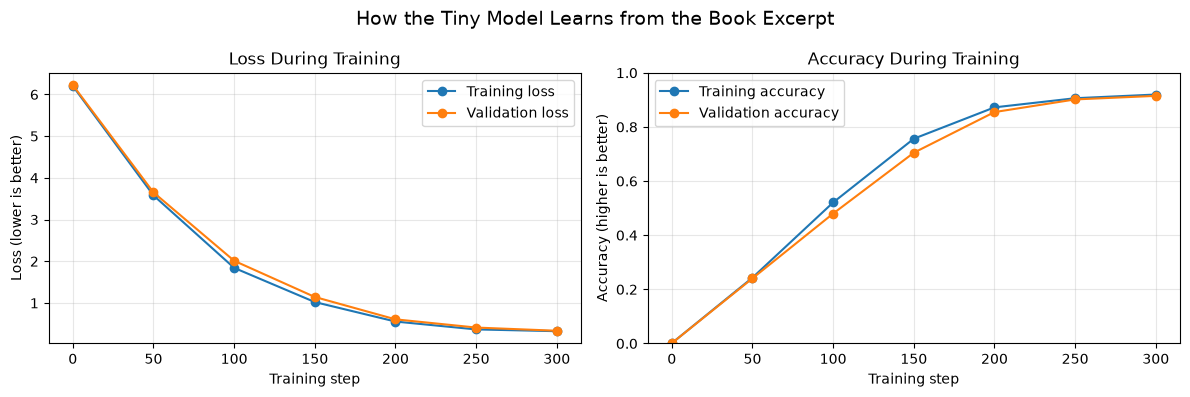

In [7]:
# Print the measurements collected during training so improvement is visible.
for row in history:
    print(
        f"step {row['step']:>3}: train loss={row['train_loss']:.3f}, val loss={row['val_loss']:.3f}, "
        f"train acc={row['train_accuracy']:.3f}, val acc={row['val_accuracy']:.3f}"
    )

# Perplexity is another way to express loss: lower values generally mean better predictions.
final_val_loss = history[-1]['val_loss']
if final_val_loss < 20:
    print('\nApproximate validation perplexity:', round(float(torch.exp(torch.tensor(final_val_loss))), 2))

# Turn the saved measurements into two easy-to-read learning-progress charts.
steps = [row['step'] for row in history]
train_losses = [row['train_loss'] for row in history]
val_losses = [row['val_loss'] for row in history]
train_accuracies = [row['train_accuracy'] for row in history]
val_accuracies = [row['val_accuracy'] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left chart: lower loss means the model's next-word predictions are less wrong.
axes[0].plot(steps, train_losses, marker='o', label='Training loss')
axes[0].plot(steps, val_losses, marker='o', label='Validation loss')
axes[0].set_title('Loss During Training')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Loss (lower is better)')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Right chart: higher accuracy means the top next-word prediction is correct more often.
axes[1].plot(steps, train_accuracies, marker='o', label='Training accuracy')
axes[1].plot(steps, val_accuracies, marker='o', label='Validation accuracy')
axes[1].set_title('Accuracy During Training')
axes[1].set_xlabel('Training step')
axes[1].set_ylabel('Accuracy (higher is better)')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle('How the Tiny Model Learns from the Book Excerpt', fontsize=14)
fig.tight_layout()
plt.show()


## Step 8: Inspect Next-Word Predictions

Now use the trained model at inference time. The weights are fixed. The model reads the prompt context and scores likely next words.


In [ ]:
# @torch.no_grad() means this is inference: inspect predictions without changing weights.
@torch.no_grad()
def top_next_words(prompt: str, top_k: int = 5):
    # Disable training-time dropout for stable inference.
    model.eval()
    # Tokenize the prompt and retain only the portion that fits in the context window.
    prompt_tokens = tokenize(prompt)
    if not prompt_tokens:
        raise ValueError('Prompt must contain at least one token.')
    prompt_ids = encode(prompt_tokens[-block_size:])
    # Put the token IDs into a one-row batch for the model.
    idx = torch.tensor([prompt_ids], dtype=torch.long, device=device)
    logits_local, _ = model(idx)
    logits_local = logits_local.view(1, len(prompt_ids), vocab_size)
    # Convert the final position's raw scores into probabilities for possible next words.
    probs = F.softmax(logits_local[0, -1], dim=-1)
    values, indices = torch.topk(probs, k=min(top_k, vocab_size))
    return [(itos[index.item()], values[position].item()) for position, index in enumerate(indices)]

# Try several contexts to see how earlier words change the next-word probabilities.
prompts = [
    "there's a cyclone",
    'dorothy soon closed her eyes and fell fast',
    'toto was not',
]

for prompt in prompts:
    print(f'Prompt: {prompt!r}')
    for token, probability in top_next_words(prompt):
        print(f'  {token:<12} {probability:.3f}')
    print()


## Step 9: Generate a Short Continuation

Generation repeats the same loop many times: predict a next token, append it, and continue.


In [ ]:
# Choose a starting context, turn it into model IDs, and generate 30 more tokens.
prompt = 'dorothy stood in the door with toto'
prompt_ids = torch.tensor([encode(tokenize(prompt))], dtype=torch.long, device=device)
# Disable dropout and reset sampling randomness for comparisons.
model.eval()
torch.manual_seed(7)
with torch.no_grad():
    generated_ids = model.generate(prompt_ids, max_new_tokens=30, temperature=0.8)[0].tolist()
# Convert the generated IDs back to readable text.
generated_text = detokenize(decode(generated_ids))

print('Prompt:\n')
print(prompt)
print('\nGenerated continuation:\n')
print(generated_text)


## Reflection

Use these questions to connect this notebook back to the Lab 0 reading:

1. What changed during training, and what stayed fixed during inference?
2. Why does the model predict different next words for different prompt contexts?
3. Why does a tiny repeated corpus help this small model learn visible patterns quickly?
4. Why is this still only a teaching model rather than a production LLM?
5. What limitation in this notebook helps explain why later labs add prompt rules, tools, and human review?


## Required Assignment: Compare Attention Heads and Training Text

Complete three runs: two on the original *Wizard of Oz* excerpt to compare attention-head counts, followed by one on a different text. Focus on observing the generated text and explaining what changed.

### Part A: Compare Four and Eight Attention Heads

An attention head learns one way of combining information from the available context. Multiple heads let the model learn different relationships in parallel. In this experiment, change only the number of attention heads.

| Run | Attention heads (`n_head`) | Embedding dimensions (`n_embd`) | Training setting (`max_iters`) |
| --- | ---: | ---: | --- |
| Baseline | 4 | 64 | `300 if device.type == 'cpu' else 500` |
| More heads | 8 | 64 | Same as baseline |

**What to do:**

1. Keep the original `wizard_of_oz_excerpt.txt` corpus. In Step 6, use `n_embd=64`, `n_head=4`, and the default `max_iters` shown above. Restart the kernel and choose **Run All**.
2. Save the generated output from Step 9 and the final recorded validation loss from Step 7. Label them **4 heads**. You may use your existing baseline results if they were produced with these settings and the current inference cells.
3. Change only `n_head` to `8` in Step 6. Restart the kernel and choose **Run All** to train a fresh model. Save the same results and label them **8 heads**.
4. Use the same device and leave all other settings unchanged. Keep the Step 9 prompt `dorothy stood in the door with toto`, temperature `0.8`, and 30 new tokens. The inference cell already disables dropout and resets the generation seed to `7` for comparison.

**What to submit:** Save both complete Step 9 outputs, then fill in this short table. Step 9 includes the prompt before the generated continuation.

| Attention heads | Final recorded validation loss (Step 7) | One observation about the generated text |
| --- | --- | --- |
| 4 | | |
| 8 | | |

**Answer these three questions in a few sentences each:**

1. What changed in the generated text when you used eight heads instead of four? Compare whether the text makes sense, repeats words, or follows the prompt. Give one example from each output. If you see little difference, say so.
2. Why might changing the number of attention heads change the output? Use this hint: with 64 embedding dimensions, four heads have 16 features each, while eight heads have 8 features each. More heads provide more separate attention operations, but each head has a smaller vector.
3. Did eight heads produce a better continuation in your two runs? Does the validation loss support your observation? Explain why more heads do not guarantee better text and why one continuation per model is not enough to prove that one setting is always better.

**How to interpret the results:** Fixed seeds help repeatability but do not make different models follow identical random trajectories. Also, the excerpt is repeated before the train/validation split, so validation can contain repeated training content. Treat the loss as a comparison within this small demonstration, not proof that the model generalizes to unseen text.

### Part B: Train on a Different Text

This required third run shows how training data shapes the model’s vocabulary, learned parameters, next-word probabilities, and generated style. Keep the baseline model settings so that the corpus is the intended change. The vocabulary size, and therefore the parameter count, may still change with the new text.

1. Choose a short public-domain text or an instructor-provided text. Do not use private, sensitive, or copyrighted text unless you have permission.
2. Save it as a UTF-8 `.txt` file in `data/`, for example `data/my_excerpt.txt`.
3. In Step 1, change the corpus path to:

```python
corpus_path = data_dir / 'my_excerpt.txt'
```

4. Restore `n_embd=64`, `n_head=4`, and `max_iters = 300 if device.type == 'cpu' else 500`. Keep the other baseline settings and the same device.
5. In Steps 8 and 9, replace the example prompts with nonempty phrases from your chosen text so their tokens are in its vocabulary. Retain the generation seed, temperature `0.8`, and 30 new tokens.
6. Restart the kernel and choose **Run All** to create and train a fresh model on the new text. You do not need to compare attention-head counts on this corpus.

**Required submission for Part B:**

- The title and source of your text, its token count and vocabulary size, and the prompts you used.
- The parameter count, training time, and a screenshot of the loss/accuracy graph.
- At least one next-word prediction with probabilities and one complete generated continuation.
- Two or three sentences comparing the output with the *Wizard of Oz* baseline and explaining how the training text influenced the result. Consider vocabulary, style, and recurring phrases; fluent output alone is not evidence of factual accuracy.

Submit Part A’s two generated outputs, comparison table, and short answers together with Part B’s results. Full training runs are part of the assignment.
